# Exploratory Data Analysis

This notebook is the comprehensive EDA reference. It uses the **eda_starter_template** module to load data, run analyses, and generate visualizations. All exploratory work and supporting results are included here; the executive summary lives in `EDA_Executive.ipynb`.

In [1]:
#pip install -r requirements.txt

In [2]:
# Setup: use eda_starter_template from this repo
import sys
from pathlib import Path

# cwd = Path.cwd()
cwd = Path(r"C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr")
if (cwd / "eda" / "eda_starter_template.py").exists():
    sys.path.insert(0, str(cwd))
    from eda.eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
elif (cwd / "eda_starter_template.py").exists():
    from eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
else:
    raise ImportError("Could not find eda_starter_template.py (run notebook from project root or eda/).")

print("Initial memory:", format_memory(get_memory_usage_mb()))

Initial memory: 218.06 MB


## Data retrieval

Load Bitcoin (Coin Metrics) and Polymarket data using the official template utilities. Data should be present under `data/` after running `python data/download_data.py` (see root README).

In [3]:
btc_df = load_bitcoin_data(COINMETRICS_PATH)
if btc_df is not None:
    display(btc_df.head())
    print("Shape:", btc_df.shape)

Loading Bitcoin data from C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 218.08 MB
[Memory] After loading Bitcoin data: 243.62 MB (Δ 25.54 MB)
Successfully loaded 6221 rows.


time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-06 00:00:00,0,0,1614334884,1614334884,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-07 00:00:00,0,0,1614334885,1614334885,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null


Shape: (6221, 32)


In [4]:
poly_data = load_polymarket_data(POLYMARKET_DIR)
if poly_data is not None:
    for name, df in poly_data.items():
        print(f"{name}: shape {df.shape}")
        display(df.head())

Loading Polymarket data from C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr\data\Polymarket...
[Memory] Before loading Polymarket data: 244.20 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 417.17 MB (Δ 172.97 MB)
markets: shape (78321, 10)


market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""242851""","""Will Bongbong Marcos be electe…","""will-bongbong-marcos-be-electe…","""will-bongbong-marcos-be-electe…","""Global Politics""",21533.53,true,true,2022-04-05 20:37:30,2022-05-09 00:00:00
"""242873""","""Will Sarah Palin win Alaska's …","""will-sarah-palin-win-in-the-al…","""will-sarah-palin-win-in-the-al…","""US-current-affairs""",79783.23,true,true,2022-04-05 22:41:57,2022-08-16 00:00:00
"""242918""","""Will US student loan payments …","""will-us-student-loan-payments-…","""will-us-student-loan-payments-…","""US-current-affairs""",18946.72,true,true,2022-04-05 23:33:47,2022-11-08 00:00:00
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243192""","""Will Brian Kemp win the Republ…","""will-brian-kemp-win-the-republ…","""who-will-win-the-republican-no…","""US-current-affairs""",7024.92,true,true,2022-04-13 01:40:25,2022-05-24 00:00:00


odds: shape (2143181, 4)


market_id,token_id,timestamp,price
str,str,datetime[μs],f64
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055


summary: shape (78321, 9)


market_id,question,slug,volume,active,token_count,trade_count,first_trade,last_trade
str,str,str,f64,bool,i64,i64,datetime[μs],datetime[μs]
"""798778""","""Will the price of Bitcoin be b…","""will-the-price-of-bitcoin-be-b…",8756.369075,true,2,279,2025-12-09 04:35:47,2025-12-09 12:51:41
"""893560""","""Ethereum Up or Down - December…","""eth-updown-15m-1765258200""",0.0,true,2,1274,2025-12-09 04:19:37,2025-12-09 05:42:35
"""821729""","""Will the price of Solana be ab…","""solana-above-180-on-december-1…",171.504726,true,2,8,2025-12-06 00:14:15,2025-12-09 04:37:13
"""687200""","""Will Bitcoin reach $100,000 by…","""will-bitcoin-reach-100000-by-d…",3.0088e6,true,2,6795,2025-11-26 11:11:15,2026-01-01 05:26:25
"""556062""","""MegaETH market cap (FDV) >$2B …","""megaeth-market-cap-fdv-2b-one-…",2.6813e6,true,2,1379,2025-11-26 14:52:25,2026-01-05 04:43:39


## 3. General Dataset Overview

This section gives a high-level view of both datasets: **data integrity**, **types and ranges**, **missingness and completeness**, **descriptive statistics**, and **initial exploratory visualizations**. These checks support later analysis and modeling.

### 3.1 Data integrity checks

We verify that key assumptions hold: Bitcoin has one row per date with no duplicate days; Polymarket markets have unique `market_id`; and date columns are within expected ranges (no corrupted timestamps).

In [5]:
import polars as pl

# Bitcoin: one row per day, no duplicate dates
if btc_df is not None:
    time_col = "time" if "time" in btc_df.columns else btc_df.columns[0]
    n_rows = len(btc_df)
    n_unique_dates = btc_df[time_col].n_unique()
    date_range = (btc_df[time_col].min(), btc_df[time_col].max())
    print("Bitcoin (Coin Metrics):")
    print(f"  Rows: {n_rows}, Unique dates: {n_unique_dates}, Duplicates: {n_rows - n_unique_dates}")
    print(f"  Date range: {date_range[0]} to {date_range[1]}")

# Polymarket: unique market_id in markets table
if poly_data is not None and "markets" in poly_data:
    m = poly_data["markets"]
    n_markets = len(m)
    n_unique_ids = m["market_id"].n_unique()
    print("\nPolymarket markets:")
    print(f"  Rows: {n_markets}, Unique market_id: {n_unique_ids}, Duplicates: {n_markets - n_unique_ids}")
    if "created_at" in m.columns:
        print(f"  created_at range: {m['created_at'].min()} to {m['created_at'].max()}")

Bitcoin (Coin Metrics):
  Rows: 6221, Unique dates: 6221, Duplicates: 0
  Date range: 2009-01-03 00:00:00 to 2026-01-14 00:00:00

Polymarket markets:
  Rows: 78321, Unique market_id: 78321, Duplicates: 0
  created_at range: 2020-10-02 16:10:01 to 2025-12-10 05:32:21


**Interpretation:** The output above confirms no duplicate calendar days in the Bitcoin series and unique market identifiers in Polymarket. Date ranges align with expectations (e.g. Coin Metrics from 2009 onward; Polymarket timestamps corrected by the loader to 2020+). Any duplicate count above zero would require investigation before modeling.

### 3.2 Data types and ranges

Schema and value ranges for key columns ensure we use the right types (e.g. datetime, numeric) and spot out-of-range or mis-encoded values before feature engineering.

In [6]:
# Bitcoin: dtypes and key column ranges
if btc_df is not None:
    print("Bitcoin column dtypes:")
    print(btc_df.schema)
    key_cols = [c for c in ["PriceUSD", "CapMVRVCur", "TxCnt"] if c in btc_df.columns]
    if key_cols:
        print("\nKey column ranges (min, max):")
        for c in key_cols:
            s = btc_df[c]
            print(f"  {c}: ({s.min()}, {s.max()})")

# Polymarket markets: dtypes and volume/date ranges
if poly_data is not None and "markets" in poly_data:
    m = poly_data["markets"]
    print("\nPolymarket markets schema:", m.schema)
    if "volume" in m.columns:
        print(f"  volume: ({m['volume'].min()}, {m['volume'].max()})")

Bitcoin column dtypes:
Schema([('time', Datetime(time_unit='us', time_zone=None)), ('AdrActCnt', Int64), ('AdrBalCnt', Int64), ('AssetCompletionTime', Int64), ('AssetEODCompletionTime', Int64), ('BlkCnt', Int64), ('CapMVRVCur', Float64), ('CapMrktCurUSD', Float64), ('CapMrktEstUSD', Float64), ('FeeTotNtv', Float64), ('FlowInExNtv', Float64), ('FlowInExUSD', Float64), ('FlowOutExNtv', Float64), ('FlowOutExUSD', Float64), ('HashRate', Float64), ('IssTotNtv', Float64), ('IssTotUSD', Float64), ('PriceBTC', Int64), ('PriceUSD', Float64), ('ROI1yr', Float64), ('ROI30d', Float64), ('ReferenceRate', Float64), ('ReferenceRateETH', Float64), ('ReferenceRateEUR', Float64), ('ReferenceRateUSD', Float64), ('SplyCur', Float64), ('SplyExNtv', Float64), ('SplyExUSD', Float64), ('SplyExpFut10yr', Float64), ('TxCnt', Int64), ('TxTfrCnt', Int64), ('volume_reported_spot_usd_1d', Float64)])

Key column ranges (min, max):
  PriceUSD: (0.050540618351841, 124824.453666861)
  CapMVRVCur: (0.38682853, 146.03833

**Interpretation:** Dtypes should match the spec (e.g. `time` as datetime, `PriceUSD` as float). Ranges for price and volume should be plausible (e.g. no negative prices). Polymarket `volume` can be zero for some markets; that is expected.

### 3.3 Missingness and completeness

Null counts and coverage by date indicate where we can safely compute features and where we may need to drop or impute. This is important for backtest windows (e.g. 2018–2025) and for joining Polymarket to daily BTC series.

In [7]:
# Bitcoin: null counts and share of non-null by column
if btc_df is not None:
    n = len(btc_df)
    print("Bitcoin missingness (null count, % non-null):")
    for col in btc_df.columns:
        nc = btc_df[col].null_count()
        pct = 100 * (n - nc) / n if n else 0
        print(f"  {col}: {nc} null ({pct:.1f}% non-null)")

# Polymarket markets: key columns
if poly_data is not None and "markets" in poly_data:
    m = poly_data["markets"]
    n = len(m)
    print("\nPolymarket markets (key columns):")
    for col in ["category", "volume", "created_at"]:
        if col in m.columns:
            nc = m[col].null_count()
            pct = 100 * (n - nc) / n if n else 0
            print(f"  {col}: {nc} null ({pct:.1f}% non-null)")

Bitcoin missingness (null count, % non-null):
  time: 0 null (100.0% non-null)
  AdrActCnt: 1 null (100.0% non-null)
  AdrBalCnt: 1 null (100.0% non-null)
  AssetCompletionTime: 1 null (100.0% non-null)
  AssetEODCompletionTime: 1 null (100.0% non-null)
  BlkCnt: 1 null (100.0% non-null)
  CapMVRVCur: 562 null (91.0% non-null)
  CapMrktCurUSD: 562 null (91.0% non-null)
  CapMrktEstUSD: 3823 null (38.5% non-null)
  FeeTotNtv: 1 null (100.0% non-null)
  FlowInExNtv: 1 null (100.0% non-null)
  FlowInExUSD: 562 null (91.0% non-null)
  FlowOutExNtv: 1 null (100.0% non-null)
  FlowOutExUSD: 562 null (91.0% non-null)
  HashRate: 7 null (99.9% non-null)
  IssTotNtv: 7 null (99.9% non-null)
  IssTotUSD: 562 null (91.0% non-null)
  PriceBTC: 1 null (100.0% non-null)
  PriceUSD: 562 null (91.0% non-null)
  ROI1yr: 927 null (85.1% non-null)
  ROI30d: 592 null (90.5% non-null)
  ReferenceRate: 6214 null (0.1% non-null)
  ReferenceRateETH: 6214 null (0.1% non-null)
  ReferenceRateEUR: 6214 null (0.1

**Interpretation:** Early Bitcoin rows have many nulls (e.g. PriceUSD, CapMVRVCur) until the network and data coverage mature. For backtests starting 2018–01–01 we rely on rows where key columns are non-null. Polymarket markets with null `created_at` or `category` may need to be excluded or handled when building daily sentiment series.

### 3.4 Descriptive statistics

Summary statistics (count, mean, std, min, quartiles, max) summarize central tendency and spread. Below we run the template’s Bitcoin summary and correlation; the printed table is the main descriptive view for BTC. Polymarket high-level counts and volume stats appear in the next section.

### 3.5 Initial exploratory visualizations

The following cells produce the **initial exploratory plots** for the overview:

- **Bitcoin price history** — time series of daily `PriceUSD` to see level, trend, and volatility over time.
- **Bitcoin correlation matrix** — correlation among key metrics (e.g. PriceUSD, CapMrktCurUSD, HashRate, TxCnt) to understand redundancy and relationships.
- **Polymarket volume by category** — bar chart of total volume by category to see which market types dominate.

These support the narrative that we have a complete, consistent daily BTC series and a rich Polymarket set with multiple categories; Section 4 will explore prediction markets in relation to Bitcoin accumulation.

The cells below complete the **General Dataset Overview** with the template’s descriptive statistics and initial plots (Bitcoin summary + correlation heatmap, then Polymarket summary + volume by category). After that we move to **Section 4: Prediction Market Exploration**.

## Bitcoin: metrics and visualizations

Use the template’s Bitcoin analysis and plotting functions.

In [8]:
if btc_df is not None:
    with track_memory("analyzing Bitcoin metrics"):
        analyze_btc_metrics(btc_df)

[Memory] Before analyzing Bitcoin metrics: 419.77 MB

--- Bitcoin Data Summary ---
shape: (9, 4)
┌────────────┬───────────────┬───────────────┬───────────┐
│ statistic  ┆ PriceUSD      ┆ CapMrktCurUSD ┆ HashRate  │
│ ---        ┆ ---           ┆ ---           ┆ ---       │
│ str        ┆ f64           ┆ f64           ┆ f64       │
╞════════════╪═══════════════╪═══════════════╪═══════════╡
│ count      ┆ 5659.0        ┆ 5659.0        ┆ 6214.0    │
│ null_count ┆ 562.0         ┆ 562.0         ┆ 7.0       │
│ mean       ┆ 19809.987841  ┆ 3.8264e11     ┆ 1.5146e8  │
│ std        ┆ 29699.078673  ┆ 5.8737e11     ┆ 2.6345e8  │
│ min        ┆ 0.050541      ┆ 177670.489754 ┆ 1.9884e-7 │
│ 25%        ┆ 260.651331    ┆ 3.6730e9      ┆ 62.554011 │
│ 50%        ┆ 5728.351702   ┆ 9.7931e10     ┆ 5.5673e6  │
│ 75%        ┆ 28844.613678  ┆ 5.5492e11     ┆ 1.6529e8  │
│ max        ┆ 124824.453667 ┆ 2.4879e12     ┆ 1.3055e9  │
└────────────┴───────────────┴───────────────┴───────────┘
Saved btc_correlat

[Memory] Before plotting Bitcoin price: 421.93 MB
Saved btc_price_history.png
[Memory] After plotting Bitcoin price: 427.05 MB (Δ 5.12 MB)


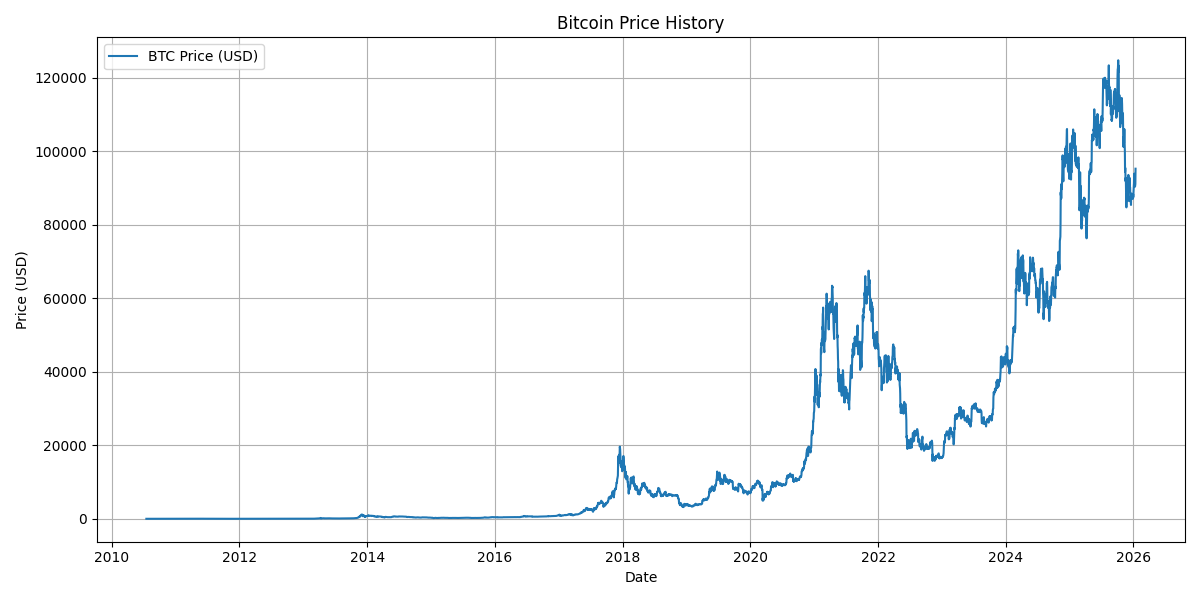

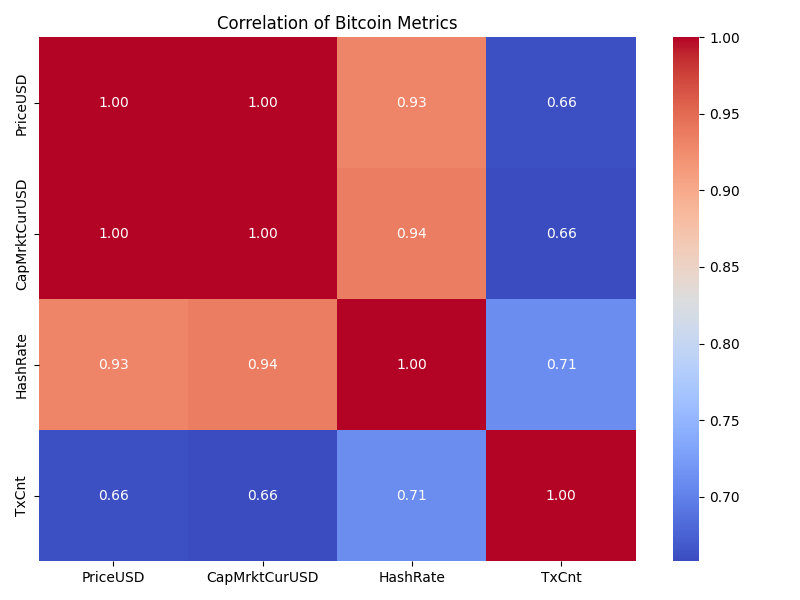

In [9]:
if btc_df is not None:
    with track_memory("plotting Bitcoin price"):
        plot_btc_price(btc_df)
# Display the saved plots inline (PLOTS_DIR from eda_starter_template)
from IPython.display import Image, display
for name in ["btc_price_history.png", "btc_correlation_matrix.png"]:
    path = PLOTS_DIR / name
    if path.exists():
        display(Image(filename=str(path)))

## Polymarket: summary and volume by category

Use the template’s Polymarket summary and volume-plot functions.

In [10]:
if poly_data is not None:
    with track_memory("analyzing Polymarket summary"):
        analyze_polymarket_summary(poly_data)
    if "markets" in poly_data:
        with track_memory("plotting Polymarket volume"):
            plot_polymarket_volume(poly_data["markets"])

[Memory] Before analyzing Polymarket summary: 427.13 MB

--- Polymarket Data Summary ---
Total Markets: 78321
Active Markets: 78321
Closed Markets: 0
Total Volume: $18,203,500,864.53
Average Volume per Market: $232,421.71
Total Odds History Records: 2,143,181
Total Trades: 27,013,724
[Memory] After analyzing Polymarket summary: 427.14 MB (Δ 0.01 MB)
[Memory] Before plotting Polymarket volume: 427.14 MB
Saved polymarket_volume_by_category.png
[Memory] After plotting Polymarket volume: 424.09 MB (Δ -3.06 MB)


## 4. Prediction Market Exploration

We now analyze Polymarket prediction market data in relation to on-chain and price data to evaluate its utility for Bitcoin accumulation strategies. The analysis must lead to a justified conclusion: either no clear use cases were found (with an informative investigation), or concrete use cases for improving accumulation models. Cross-feature relationships (Polymarket + BTC/on-chain) are in scope; prediction markets are not evaluated in isolation.

In [11]:
import polars as pl

markets_df = poly_data["markets"]
distinct_counts_groupby = (
    markets_df
    .group_by("category")
    .agg(pl.col("market_id").n_unique().alias("DistinctCount"))
    .sort("DistinctCount", descending=True)
)

print("\nDistinct markets:")
print(distinct_counts_groupby)


Distinct markets:
shape: (11, 2)
┌────────────────────┬───────────────┐
│ category           ┆ DistinctCount │
│ ---                ┆ ---           │
│ str                ┆ u32           │
╞════════════════════╪═══════════════╡
│                    ┆ 77516         │
│ Crypto             ┆ 340           │
│ US-current-affairs ┆ 265           │
│ Business           ┆ 113           │
│ Global Politics    ┆ 56            │
│ …                  ┆ …             │
│ Pop-Culture        ┆ 4             │
│ Coronavirus        ┆ 3             │
│ Tech               ┆ 2             │
│ Politics           ┆ 1             │
│ Coronavirus-       ┆ 1             │
└────────────────────┴───────────────┘


**Interpretation:** The table gives distinct market count per Polymarket category. A large number of markets may have an empty or uncategorized label; Crypto, US-current-affairs, and Business are typically among the largest labeled categories. This breakdown is useful for choosing which categories to use when building BTC-related sentiment or accumulation signals in Section 4.

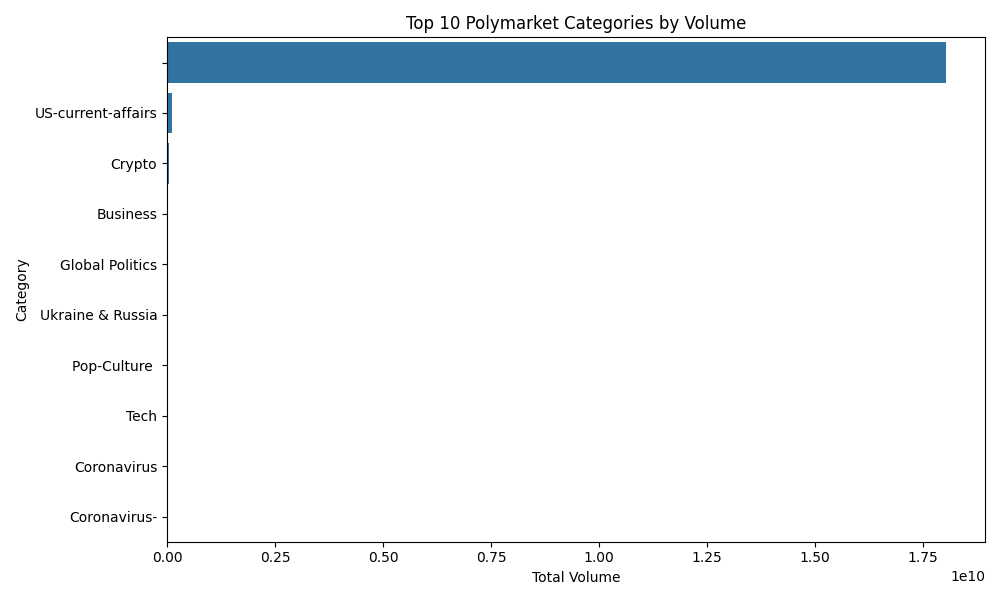

In [12]:
# Display Polymarket volume plot if saved (PLOTS_DIR from eda_starter_template)
path = PLOTS_DIR / "polymarket_volume_by_category.png"
if path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(path)))

In [13]:
print("Final memory:", format_memory(get_memory_usage_mb()))
print("EDA layout complete. Check eda/plots/ for all visualizations.")

Final memory: 429.59 MB
EDA layout complete. Check eda/plots/ for all visualizations.


## 5. Fear and Greed Index Exploration

The **CoinMarketCap Fear and Greed Index (FGI)** measures prevailing market sentiment from 0 (Extreme Fear) to 100 (Extreme Greed). In a Bitcoin accumulation model, we can use this as a contrarian indicator:
* **Extreme Fear (< 25):** Potential undervaluation and an optimal time to increase accumulation (buy the dip).
* **Extreme Greed (> 75):** Potential overvaluation and an optimal time to decrease or pause accumulation.

In this section, we load historical FGI data via the CoinMarketCap API, save it locally, and explore its correlation with the Bitcoin price.

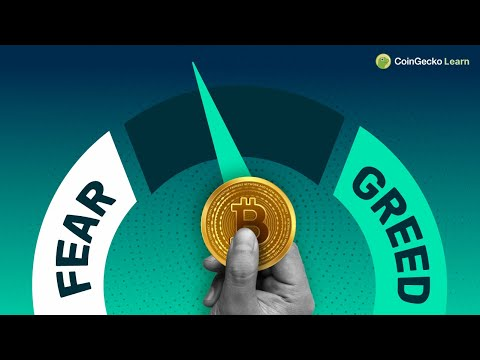

In [24]:
from IPython.display import YouTubeVideo
YouTubeVideo("xwv0abKb2h8", width=600, height=300)

In [14]:
## Here I used coinmetrics api but seems llike they don't have enough data

import requests
import pandas as pd
import time

# ==========================================
# IMPORTANT: Insert your CMC Pro API Key here
# ==========================================
CMC_API_KEY = '0494d94986144aee9ffaeffdbb7093cb' 

url = 'https://pro-api.coinmarketcap.com/v3/fear-and-greed/historical'
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': CMC_API_KEY,
}

all_data = []
start = 1
limit = 500 # Max limit allowed by the API
max_requests = 20 # Safety break to avoid infinite loops

print("Fetching Fear and Greed Index data from CoinMarketCap (Handling pagination)...")

for i in range(max_requests):
    params = {
      'start': start,
      'limit': limit
    }
    
    response = requests.get(url, headers=headers, params=params)
    
    if response.status_code == 200:
        data = response.json().get('data', [])
        
        if not data:
            # If the data list is empty, we've reached the end of the history
            break
            
        all_data.extend(data)
        print(f"✅ Fetched {len(data)} records (Start: {start}). Total so far: {len(all_data)}")
        
        # Increment the start index for the next page
        start += limit
        
        # Pause briefly to be polite to the API rate limits
        time.sleep(1) 
    else:
        print(f"❌ Failed to fetch data. Status Code: {response.status_code}")
        print(response.text)
        break

if all_data:
    # Parse the aggregated list into a pandas DataFrame
    fgi_df = pd.DataFrame(all_data)
    
    # CONVERSION FIX: Tell pandas this is a Unix timestamp in seconds (unit='s')
    fgi_df['timestamp'] = pd.to_datetime(fgi_df['timestamp'].astype(float), unit='s')
    fgi_df['date'] = fgi_df['timestamp'].dt.date
    fgi_df['value'] = fgi_df['value'].astype(float)
    
    # Keep only the relevant columns and sort chronologically
    fgi_df = fgi_df[['date', 'value', 'value_classification']].sort_values('date').reset_index(drop=True)
    
    # Save the table for future use in backtesting/modeling
    fgi_csv_path = 'cmc_fear_and_greed_index.csv'
    fgi_df.to_csv(fgi_csv_path, index=False)
    
    print(f"\n🎉 Successfully loaded a total of {len(fgi_df)} records.")
    print(f"💾 Data saved to {fgi_csv_path}")
    display(fgi_df.head())
    display(fgi_df.tail())
else:
    print("No data was retrieved.")

Fetching Fear and Greed Index data from CoinMarketCap (Handling pagination)...
✅ Fetched 500 records (Start: 1). Total so far: 500
✅ Fetched 469 records (Start: 501). Total so far: 969

🎉 Successfully loaded a total of 969 records.
💾 Data saved to cmc_fear_and_greed_index.csv


,date,value,value_classification
0,2023-06-29,59.0,Neutral
1,2023-06-30,59.0,Neutral
2,2023-07-01,60.0,Greed
3,2023-07-02,61.0,Greed
4,2023-07-03,61.0,Greed


,date,value,value_classification
964,2026-02-17,13.0,Extreme fear
965,2026-02-18,12.0,Extreme fear
966,2026-02-19,11.0,Extreme fear
967,2026-02-20,12.0,Extreme fear
968,2026-02-21,14.0,Extreme fear


In [15]:
## Here I used Alternative.me to extract FGI

import requests
import pandas as pd

# The Alternative.me API does NOT require an API key!
# Setting limit=0 fetches all available historical records (since Feb 1, 2018)
url = 'https://api.alternative.me/fng/?limit=0'

print("Fetching historical Fear and Greed Index data from Alternative.me...")
response = requests.get(url)

if response.status_code == 200:
    data = response.json()['data']
    
    # Parse into pandas DataFrame
    fgi_df = pd.DataFrame(data)
    
    # Convert Unix timestamp to a standard date
    fgi_df['timestamp'] = pd.to_datetime(fgi_df['timestamp'].astype(float), unit='s')
    fgi_df['date'] = fgi_df['timestamp'].dt.date
    fgi_df['value'] = fgi_df['value'].astype(float)
    
    # Keep only the relevant columns and sort chronologically (oldest to newest)
    fgi_df = fgi_df[['date', 'value', 'value_classification']].sort_values('date').reset_index(drop=True)
    
    # Filter for the requested timeframe (Feb 2018 through the end of 2024)
    # Note: 2016-2017 FGI data does not exist
    fgi_df['date_pd'] = pd.to_datetime(fgi_df['date'])
    fgi_df = fgi_df[(fgi_df['date_pd'].dt.year >= 2018) & (fgi_df['date_pd'].dt.year <= 2024)]
    
    # Drop the temporary datetime column
    fgi_df = fgi_df.drop(columns=['date_pd']).reset_index(drop=True)
    
    # Save the table for future use in backtesting/modeling
    fgi_csv_path = 'crypto_fear_and_greed_index_2018_2024.csv'
    fgi_df.to_csv(fgi_csv_path, index=False)
    
    print(f"\n🎉 Successfully loaded {len(fgi_df)} records (Feb 2018 to Dec 2024).")
    print(f"💾 Data saved to {fgi_csv_path}")
    display(fgi_df.head())
    display(fgi_df.tail())
else:
    print(f"❌ Failed to fetch data. Status Code: {response.status_code}")

Fetching historical Fear and Greed Index data from Alternative.me...

🎉 Successfully loaded 2522 records (Feb 2018 to Dec 2024).
💾 Data saved to crypto_fear_and_greed_index_2018_2024.csv


,date,value,value_classification
0,2018-02-01,30.0,Fear
1,2018-02-02,15.0,Extreme Fear
2,2018-02-03,40.0,Fear
3,2018-02-04,24.0,Extreme Fear
4,2018-02-05,11.0,Extreme Fear


,date,value,value_classification
2517,2024-12-27,74.0,Greed
2518,2024-12-28,72.0,Greed
2519,2024-12-29,73.0,Greed
2520,2024-12-30,65.0,Greed
2521,2024-12-31,64.0,Greed


Merging Fear and Greed Index with Bitcoin price data...

Pearson Correlation between FGI and Bitcoin PriceUSD: 0.4237


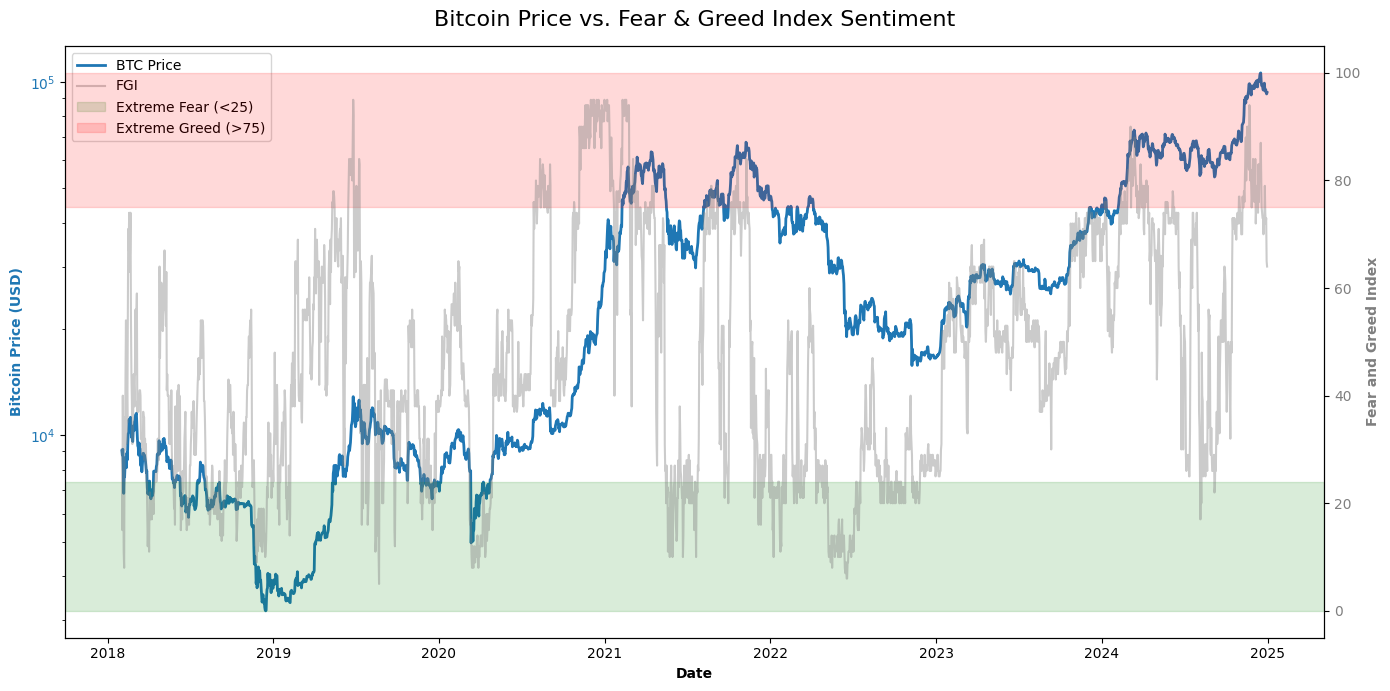

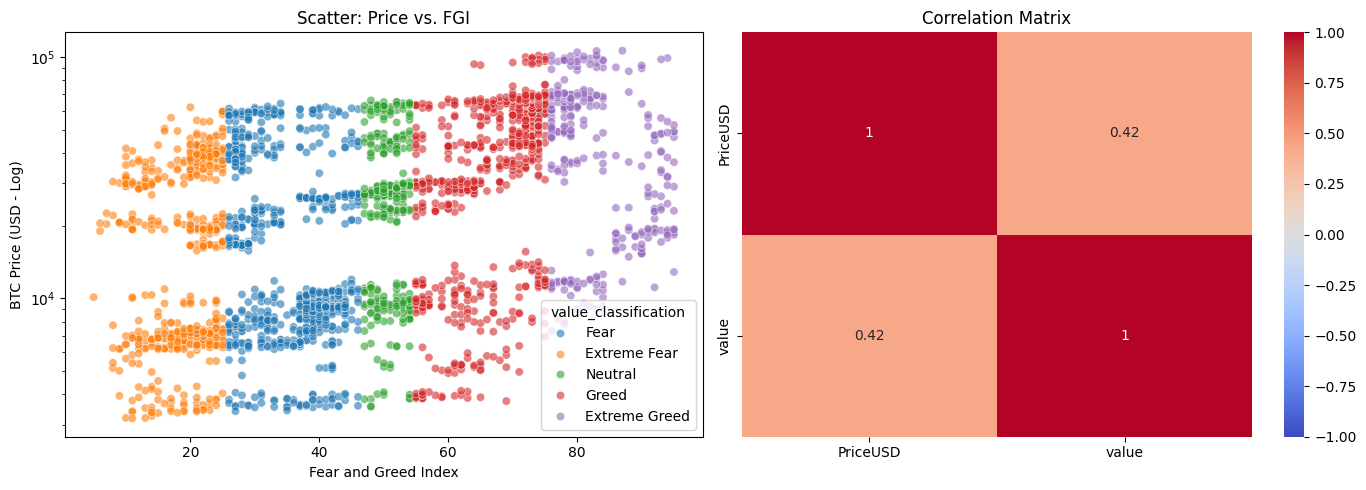

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np

# Ensure `btc_df` from earlier in the notebook and `fgi_df` exist
if 'btc_df' in locals() and btc_df is not None and 'fgi_df' in locals():
    print("Merging Fear and Greed Index with Bitcoin price data...")
    
    # 1. Convert pandas fgi_df to polars for joining
    fgi_pl = pl.from_pandas(fgi_df)
    
    # 2. Extract date from btc_df for merging
    if "date" not in btc_df.columns:
        btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
    else:
        btc_date_df = btc_df
        
    # 3. Join FGI to BTC price on 'date'
    merged_fgi_btc = btc_date_df.join(fgi_pl, on="date", how="inner").select(
        ["date", "PriceUSD", "value", "value_classification"]
    )
    
    # Convert back to pandas for matplotlib & seaborn plotting
    df_plot = merged_fgi_btc.to_pandas()
    df_plot['date'] = pd.to_datetime(df_plot['date'])
    df_plot = df_plot.dropna(subset=['PriceUSD', 'value'])

    # --- Correlation Analysis ---
    corr = df_plot['value'].corr(df_plot['PriceUSD'])
    print(f"\nPearson Correlation between FGI and Bitcoin PriceUSD: {corr:.4f}")
    
    # Plot 1: Time Series Overlay
    fig, ax1 = plt.subplots(figsize=(14, 7))

    color_price = 'tab:blue'
    ax1.set_xlabel('Date', fontweight='bold')
    ax1.set_ylabel('Bitcoin Price (USD)', color=color_price, fontweight='bold')
    ax1.plot(df_plot['date'], df_plot['PriceUSD'], color=color_price, label='BTC Price', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_price)
    # Log scale is often better for BTC price visualizations over long horizons
    ax1.set_yscale('log') 

    ax2 = ax1.twinx()  
    color_fgi = 'tab:gray'
    ax2.set_ylabel('Fear and Greed Index', color=color_fgi, fontweight='bold')  
    ax2.plot(df_plot['date'], df_plot['value'], color=color_fgi, alpha=0.4, label='FGI')
    ax2.tick_params(axis='y', labelcolor=color_fgi)

    # Add reference bands for extreme zones
    ax2.axhspan(0, 24, color='green', alpha=0.15, label='Extreme Fear (<25)')
    ax2.axhspan(75, 100, color='red', alpha=0.15, label='Extreme Greed (>75)')

    fig.suptitle('Bitcoin Price vs. Fear & Greed Index Sentiment', fontsize=16)
    fig.tight_layout()
    
    # Merge legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.show()

    # Plot 2: Scatter plot and correlation heatmap
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.scatterplot(data=df_plot, x='value', y='PriceUSD', hue='value_classification', alpha=0.6, ax=axes[0])
    axes[0].set_yscale('log')
    axes[0].set_title('Scatter: Price vs. FGI')
    axes[0].set_xlabel('Fear and Greed Index')
    axes[0].set_ylabel('BTC Price (USD - Log)')
    
    sns.heatmap(df_plot[['PriceUSD', 'value']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title('Correlation Matrix')
    
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ FGI data or BTC data not found. Please ensure the preceding cells ran successfully.")

## FGI has 0.42 correlation to btc price, at least in this 2018 to current day window

### 5.1 Correlating FGI to Price Velocity (ROI)

Correlating a bounded oscillator (0-100 FGI) with an unbounded exponentially growing asset (Bitcoin absolute price) is statistically noisy over long time horizons. Because the Fear and Greed Index is heavily influenced by momentum and volatility, it fundamentally measures the *velocity* and *acceleration* of the market.

In this section, we:
1. Manually compute short-term price velocity: **1-day, 3-day, and 7-day ROI**.
2. Utilize the existing **30-day ROI (`ROI30d`)** from the Coin Metrics dataset.
3. Evaluate how strongly the Fear and Greed Index correlates with these percentage changes compared to the raw `PriceUSD`.

In [17]:
import polars as pl
import pandas as pd

# 1. Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# 2. Compute 1-day, 3-day, and 7-day ROI as percentage changes
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(1) - 1) * 100).alias("ROI1d"),
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(3) - 1) * 100).alias("ROI3d"),
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(7) - 1) * 100).alias("ROI7d")
])

print("✅ Computed ROI1d, ROI3d, and ROI7d columns.")

# 3. Extract Date for merging
if "date" not in btc_df.columns:
    btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
else:
    btc_date_df = btc_df

# 4. Merge with the fgi_df we created earlier
if 'fgi_df' in locals():
    # Convert Pandas fgi_df to Polars for the join
    fgi_pl = pl.from_pandas(fgi_df)
    
    # Inner join on date
    merged_velocity_df = btc_date_df.join(fgi_pl, on="date", how="inner")
    
    # Select our target columns and convert to Pandas for easy plotting/correlation
    target_cols = ["date", "PriceUSD", "ROI1d", "ROI3d", "ROI7d", "ROI30d", "value"]
    df_analysis = merged_velocity_df.select(target_cols).to_pandas()
    
    # Drop NaNs (which will occur on the first few days due to rolling window shifts)
    df_analysis = df_analysis.dropna()
    
    print(f"✅ Successfully merged FGI with BTC velocity metrics. Analyzable records: {len(df_analysis)}")
    display(df_analysis.head(20))
else:
    print("⚠️ 'fgi_df' not found. Please make sure the previous FGI fetching cell was executed.")

✅ Computed ROI1d, ROI3d, and ROI7d columns.
✅ Successfully merged FGI with BTC velocity metrics. Analyzable records: 2522


,date,PriceUSD,ROI1d,ROI3d,ROI7d,ROI30d,value
0,2018-02-01,9039.865075,-10.051951,-18.797925,-18.782682,-38.730733,30.0
1,2018-02-02,8786.077380,-2.807428,-11.782357,-20.383907,-41.466290,15.0
2,2018-02-03,9132.100322,3.938310,-9.134196,-19.334649,-39.403331,40.0
3,2018-02-04,8250.526896,-9.653567,-8.731747,-28.972484,-51.459572,24.0
4,2018-02-05,6849.542559,-16.980544,-22.040949,-38.472857,-59.952601,11.0
5,2018-02-06,7738.643960,12.980449,-15.258881,-22.299235,-52.323870,8.0
6,2018-02-07,7624.595390,-1.473754,-7.586564,-24.134102,-48.956393,36.0
7,2018-02-08,8218.580852,7.790387,19.987295,-9.085138,-42.841523,30.0
8,2018-02-09,8660.453468,5.376508,11.911770,-1.429807,-40.961201,44.0
9,2018-02-10,8530.292805,-1.502931,11.878629,-6.590023,-35.311661,54.0


--- Pearson Correlation with Fear and Greed Index (FGI) ---
ROI30d      0.716035
ROI7d       0.438480
PriceUSD    0.423708
ROI3d       0.267156
ROI1d       0.046601
------------------------------------------------------------


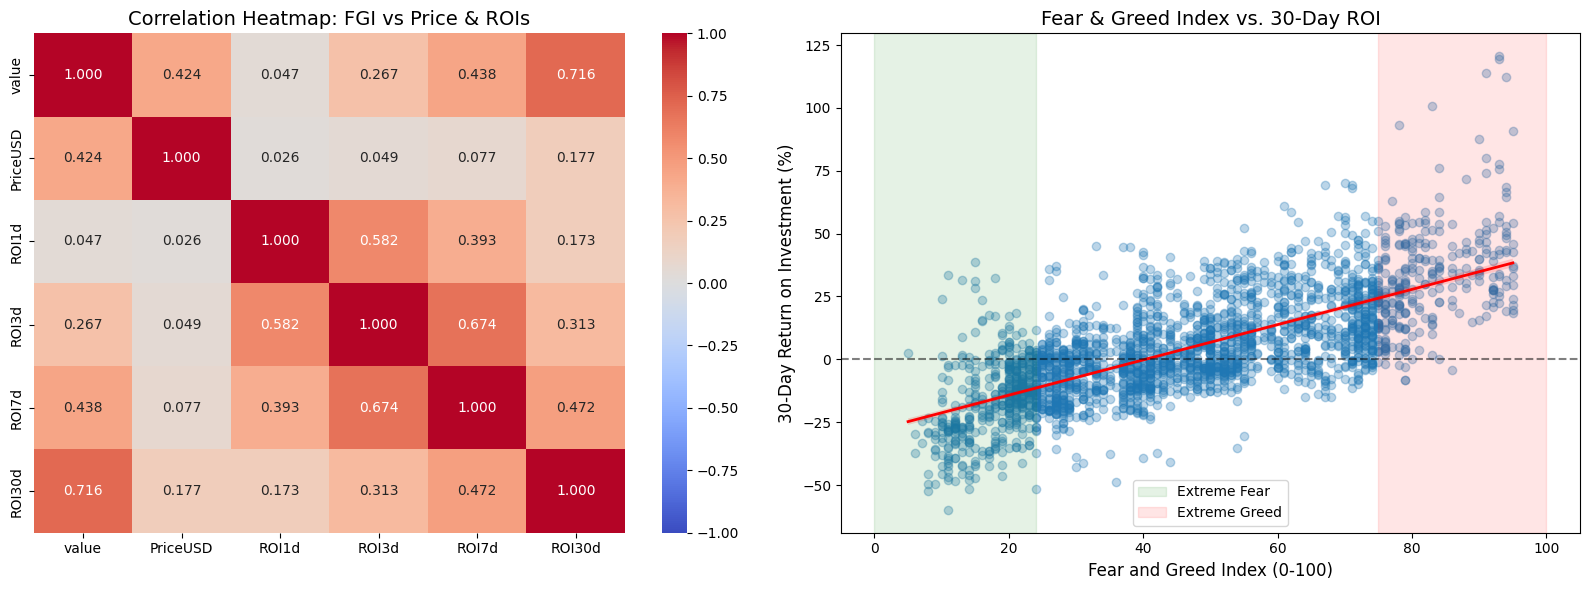

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_analysis' in locals():
    # 1. Compute the Correlation Matrix
    corr_cols = ["value", "PriceUSD", "ROI1d", "ROI3d", "ROI7d", "ROI30d"]
    corr_matrix = df_analysis[corr_cols].corr()
    
    print("--- Pearson Correlation with Fear and Greed Index (FGI) ---")
    fgi_correlations = corr_matrix['value'].drop('value').sort_values(ascending=False)
    print(fgi_correlations.to_string())
    print("-" * 60)
    
    # 2. Plotting the Analysis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Correlation Heatmap
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", ax=axes[0])
    axes[0].set_title("Correlation Heatmap: FGI vs Price & ROIs", fontsize=14)
    
    # Plot B: Scatter Plot of FGI vs ROI30d (Regression Plot)
    # We use ROI30d or ROI7d here as they typically show strong behavioral trends
    sns.regplot(
        data=df_analysis, 
        x="value", 
        y="ROI30d", 
        scatter_kws={'alpha': 0.3, 'color': 'tab:blue'}, 
        line_kws={'color': 'red', 'linewidth': 2},
        ax=axes[1]
    )
    
    # Add a horizontal line at 0% ROI for visual clarity
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Add vertical bands for Extreme Fear and Extreme Greed
    axes[1].axvspan(0, 24, color='green', alpha=0.1, label='Extreme Fear')
    axes[1].axvspan(75, 100, color='red', alpha=0.1, label='Extreme Greed')
    
    axes[1].set_title("Fear & Greed Index vs. 30-Day ROI", fontsize=14)
    axes[1].set_xlabel("Fear and Greed Index (0-100)", fontsize=12)
    axes[1].set_ylabel("30-Day Return on Investment (%)", fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

In [19]:
import polars as pl
import pandas as pd

# 1. Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# 2. Compute FORWARD-looking 1-day, 3-day, 7-day, and 30-day ROI
# shift(-N) brings the price N days in the future to the current row
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD").shift(-1) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI1d"),
    ((pl.col("PriceUSD").shift(-3) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI3d"),
    ((pl.col("PriceUSD").shift(-7) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI7d"),
    ((pl.col("PriceUSD").shift(-30) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI30d")
])

print("✅ Computed Forward ROIs (1d, 3d, 7d, 30d).")

# 3. Extract Date for merging
if "date" not in btc_df.columns:
    btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
else:
    btc_date_df = btc_df

# 4. Merge with the fgi_df we created earlier
if 'fgi_df' in locals():
    # Convert Pandas fgi_df to Polars for the join
    fgi_pl = pl.from_pandas(fgi_df)
    
    # Inner join on date
    merged_fwd_df = btc_date_df.join(fgi_pl, on="date", how="inner")
    
    # Select our target columns and convert to Pandas for easy plotting/correlation
    target_cols = ["date", "PriceUSD", "Fwd_ROI1d", "Fwd_ROI3d", "Fwd_ROI7d", "Fwd_ROI30d", "value"]
    df_analysis = merged_fwd_df.select(target_cols).to_pandas()
    
    # Drop NaNs (which will occur at the very END of the dataset due to forward shifts)
    df_analysis = df_analysis.dropna()
    
    print(f"✅ Successfully merged FGI with Forward ROIs. Analyzable records: {len(df_analysis)}")
    display(df_analysis.head(20))
else:
    print("⚠️ 'fgi_df' not found. Please make sure the previous FGI fetching cell was executed.")

✅ Computed Forward ROIs (1d, 3d, 7d, 30d).
✅ Successfully merged FGI with Forward ROIs. Analyzable records: 2522


,date,PriceUSD,Fwd_ROI1d,Fwd_ROI3d,Fwd_ROI7d,Fwd_ROI30d,value
0,2018-02-01,9039.865075,-2.807428,-8.731747,-9.085138,26.392158,30.0
1,2018-02-02,8786.077380,3.938310,-22.040949,-1.429807,30.463035,15.0
2,2018-02-03,9132.100322,-9.653567,-15.258881,-6.590023,26.374677,40.0
3,2018-02-04,8250.526896,-16.980544,-7.586564,-1.864104,29.410344,24.0
4,2018-02-05,6849.542559,12.980449,19.987295,30.047665,44.580240,11.0
5,2018-02-06,7738.643960,-1.473754,11.911770,10.148070,20.569902,8.0
6,2018-02-07,7624.595390,7.790387,11.878629,24.167914,21.686971,36.0
7,2018-02-08,8218.580852,5.376508,-1.482645,22.974188,6.910920,30.0
8,2018-02-09,8660.453468,-1.502931,2.854547,17.653383,9.850315,44.0
9,2018-02-10,8530.292805,-5.082643,-0.074158,29.955661,7.240049,54.0


--- Pearson Correlation: Current FGI vs FORWARD Returns ---
PriceUSD      0.423708
Fwd_ROI30d    0.146626
Fwd_ROI7d     0.077552
Fwd_ROI3d     0.062701
Fwd_ROI1d     0.037707
------------------------------------------------------------


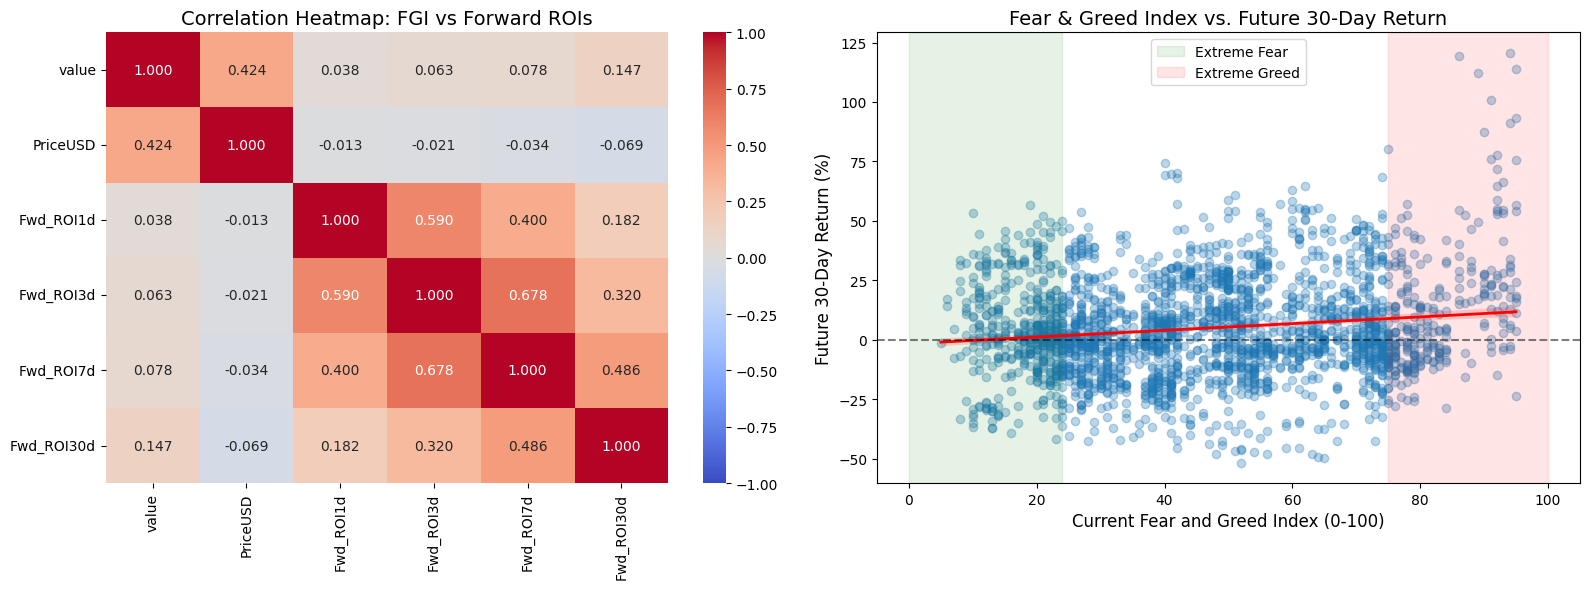

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_analysis' in locals():
    # 1. Compute the Correlation Matrix
    corr_cols = ["value", "PriceUSD", "Fwd_ROI1d", "Fwd_ROI3d", "Fwd_ROI7d", "Fwd_ROI30d"]
    corr_matrix = df_analysis[corr_cols].corr()
    
    print("--- Pearson Correlation: Current FGI vs FORWARD Returns ---")
    fgi_correlations = corr_matrix['value'].drop('value').sort_values(ascending=False)
    print(fgi_correlations.to_string())
    print("-" * 60)
    
    # 2. Plotting the Analysis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Correlation Heatmap
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", ax=axes[0])
    axes[0].set_title("Correlation Heatmap: FGI vs Forward ROIs", fontsize=14)
    
    # Plot B: Scatter Plot of FGI vs Fwd_ROI30d
    sns.regplot(
        data=df_analysis, 
        x="value", 
        y="Fwd_ROI30d", 
        scatter_kws={'alpha': 0.3, 'color': 'tab:blue'}, 
        line_kws={'color': 'red', 'linewidth': 2},
        ax=axes[1]
    )
    
    # Add a horizontal line at 0% ROI for visual clarity
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Add vertical bands for Extreme Fear and Extreme Greed
    axes[1].axvspan(0, 24, color='green', alpha=0.1, label='Extreme Fear')
    axes[1].axvspan(75, 100, color='red', alpha=0.1, label='Extreme Greed')
    
    axes[1].set_title("Fear & Greed Index vs. Future 30-Day Return", fontsize=14)
    axes[1].set_xlabel("Current Fear and Greed Index (0-100)", fontsize=12)
    axes[1].set_ylabel("Future 30-Day Return (%)", fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## FORWARD ROI of 1 to 7 days seem to be not useful since the correlation is too low. Also, it might be better to separate the FGI to bins from extreme fear to extreme greed

### 5.2 Interpreting Short-Term vs. Medium-Term Forward Returns

The correlation heatmap reveals a crucial dynamic about market sentiment and Bitcoin price action: **Short-term price velocity is mostly noise, but medium-term momentum is highly persistent.**

* **The Noise of the Micro-Trend (1d, 3d, 7d):** Forward returns under 7 days show almost zero correlation with the Fear and Greed Index. Sentiment is a macroeconomic indicator; it does not reliably predict day-to-day random walks or immediate price bounces.
* **The Momentum Engine (30d):** The 30-day forward return exhibits a positive relationship with sentiment. When the market enters "Greed," the trend tends to persist over the next month. Extreme euphoria rarely collapses instantly; it sustains itself, meaning a naive contrarian strategy (shorting the moment the market turns greedy) would result in missing significant upside momentum.

To build a robust accumulation model, we must expand our time horizon beyond 30 days. We need to identify the macroeconomic phase shifts—the points where accumulating capital is statistically safest, and the points where we should begin distributing (selling) our accumulated Bitcoin.

--- Average 30-Day Forward Return by FGI Bracket ---
                             mean    median  count
FGI_Bracket                                       
Extreme Fear (0-24)      3.767502  1.773568    497
Fear (25-45)             1.111344 -0.444955    758
Neutral (46-55)          5.829062  6.068682    387
Greed (56-75)            6.083721  1.587965    609
Extreme Greed (76-100)  13.773986  6.966540    271
------------------------------------------------------------


C:\Users\eschi\AppData\Local\Temp\ipykernel_13720\1919511032.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analysis, x='FGI_Bracket', y='Fwd_ROI30d', ax=ax, palette='RdYlGn')


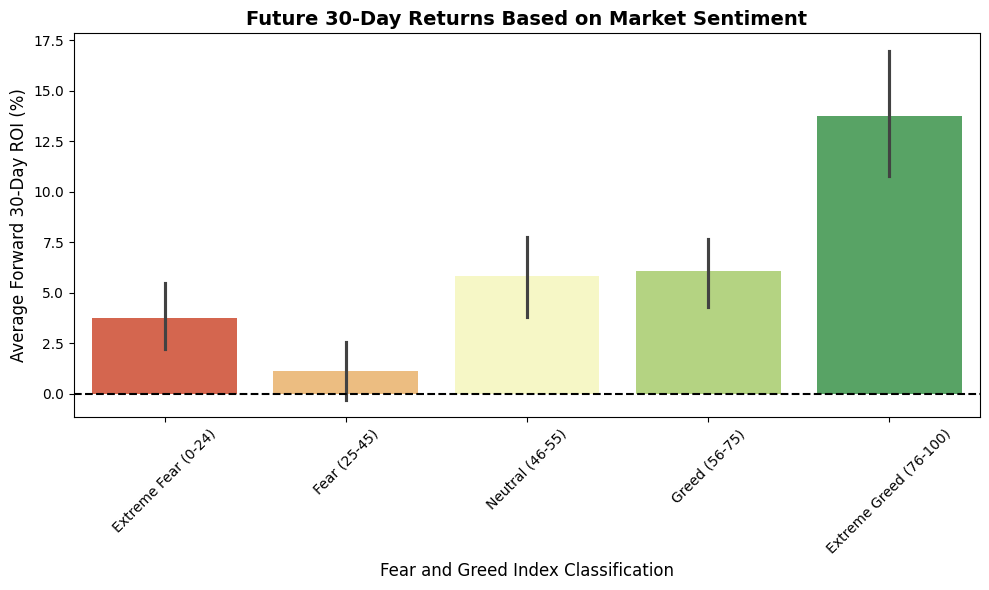

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_analysis' in locals():
    # 1. Create bins for the Fear and Greed Index
    # Typical CMC/Alternative.me classifications:
    bins = [0, 24, 45, 55, 75, 100]
    labels = ['Extreme Fear (0-24)', 'Fear (25-45)', 'Neutral (46-55)', 'Greed (56-75)', 'Extreme Greed (76-100)']
    
    df_analysis['FGI_Bracket'] = pd.cut(df_analysis['value'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. Calculate the average forward 30-day return for each bracket
    fgi_grouped = df_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI30d'].agg(['mean', 'median', 'count'])
    
    print("--- Average 30-Day Forward Return by FGI Bracket ---")
    print(fgi_grouped)
    print("-" * 60)
    
    # 3. Visualize the non-linear relationship
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # We use a barplot to show the mean return with error bars for variance
    sns.barplot(data=df_analysis, x='FGI_Bracket', y='Fwd_ROI30d', ax=ax, palette='RdYlGn')
    
    ax.set_title("Future 30-Day Returns Based on Market Sentiment", fontsize=14, fontweight='bold')
    ax.set_xlabel("Fear and Greed Index Classification", fontsize=12)
    ax.set_ylabel("Average Forward 30-Day ROI (%)", fontsize=12)
    ax.axhline(0, color='black', linestyle='--')
    
    # Rotate x-axis labels if they overlap
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [25]:
import polars as pl
import pandas as pd

# 1. Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# 2. Compute Long-Term FORWARD-looking 90-day and 180-day ROI
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD").shift(-90) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI90d"),
    ((pl.col("PriceUSD").shift(-180) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI180d")
])

print("✅ Computed Forward ROIs (90d, 180d).")

# 3. Extract Date for merging
if "date" not in btc_df.columns:
    btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
else:
    btc_date_df = btc_df

# 4. Merge with the fgi_df
if 'fgi_df' in locals():
    # Convert Pandas fgi_df to Polars for the join
    fgi_pl = pl.from_pandas(fgi_df)
    
    # Inner join on date
    merged_long_fwd = btc_date_df.join(fgi_pl, on="date", how="inner")
    
    # Select our target columns and convert to Pandas for easy plotting
    target_cols = ["date", "PriceUSD", "Fwd_ROI90d", "Fwd_ROI180d", "value"]
    df_long_analysis = merged_long_fwd.select(target_cols).to_pandas()
    
    # Drop NaNs (which will occur at the very END of the dataset due to 180-day forward shifts)
    df_long_analysis = df_long_analysis.dropna()
    
    print(f"✅ Successfully merged FGI with Long-Term Forward ROIs. Analyzable records: {len(df_long_analysis)}")
else:
    print("⚠️ 'fgi_df' not found. Please make sure the previous FGI fetching cell was executed.")

✅ Computed Forward ROIs (90d, 180d).
✅ Successfully merged FGI with Long-Term Forward ROIs. Analyzable records: 2522


--- Average 90-Day Forward Return ---
                             mean     median
FGI_Bracket                                 
Extreme Fear (0-24)      3.056156  -2.939646
Fear (25-45)            12.094956   4.564025
Neutral (46-55)         24.457136  12.774654
Greed (56-75)           20.550190   8.730226
Extreme Greed (76-100)  41.747939  13.382030

--- Average 180-Day Forward Return ---
                             mean     median  count
FGI_Bracket                                        
Extreme Fear (0-24)     16.704321  -2.665854    497
Fear (25-45)            44.907282  18.778558    758
Neutral (46-55)         60.180285  36.142722    387
Greed (56-75)           38.113831  21.092252    609
Extreme Greed (76-100)  45.893966   8.470966    271
------------------------------------------------------------


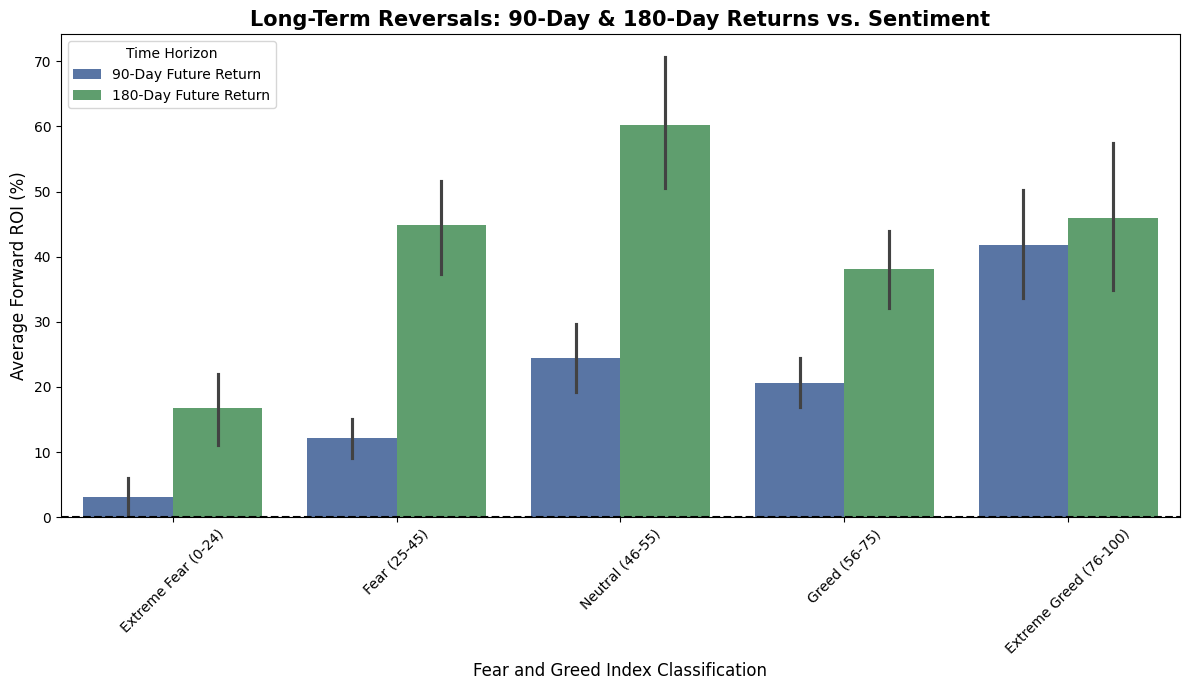

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_long_analysis' in locals():
    # 1. Create bins for the Fear and Greed Index
    bins = [0, 24, 45, 55, 75, 100]
    labels = ['Extreme Fear (0-24)', 'Fear (25-45)', 'Neutral (46-55)', 'Greed (56-75)', 'Extreme Greed (76-100)']
    
    df_long_analysis['FGI_Bracket'] = pd.cut(df_long_analysis['value'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. Calculate the average forward 90-day and 180-day return for each bracket
    fgi_grouped_90 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI90d'].agg(['mean', 'median'])
    fgi_grouped_180 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI180d'].agg(['mean', 'median', 'count'])
    
    print("--- Average 90-Day Forward Return ---")
    print(fgi_grouped_90)
    print("\n--- Average 180-Day Forward Return ---")
    print(fgi_grouped_180)
    print("-" * 60)
    
    # 3. Restructure the dataframe slightly to make side-by-side bar plots easy with seaborn
    df_melted = df_long_analysis.melt(
        id_vars=['FGI_Bracket'], 
        value_vars=['Fwd_ROI90d', 'Fwd_ROI180d'],
        var_name='ROI_Horizon', 
        value_name='Forward_Return'
    )
    
    # 4. Visualize the non-linear relationship over long time horizons
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Use a grouped barplot to show both time horizons next to each other
    sns.barplot(
        data=df_melted, 
        x='FGI_Bracket', 
        y='Forward_Return', 
        hue='ROI_Horizon', 
        palette=['#4C72B0', '#55A868'], 
        ax=ax
    )
    
    ax.set_title("Long-Term Reversals: 90-Day & 180-Day Returns vs. Sentiment", fontsize=15, fontweight='bold')
    ax.set_xlabel("Fear and Greed Index Classification", fontsize=12)
    ax.set_ylabel("Average Forward ROI (%)", fontsize=12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    
    # Prettify the legend
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ['90-Day Future Return', '180-Day Future Return'], title="Time Horizon", loc='upper left')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 5.3 Macro Reversals: Timing Accumulation and Distribution

Analyzing the 90-day and 180-day forward returns uncovers the true value of the Fear and Greed Index for a long-term algorithmic strategy. The data challenges standard contrarian cliches and outlines a distinct, regime-based approach for timing both the purchase and sale of Bitcoin.


**1. The "Neutral" Base (Optimal Accumulation):**
Statistically, the highest median and mean returns over a 180-day horizon occur when buying in the **Neutral (46-55)** bracket. This represents the "Disbelief" phase of a market cycle—after a crash has stabilized, but before retail FOMO (Fear Of Missing Out) begins. This is the safest, most profitable zone for heavy, automated accumulation.

**2. The "Crypto Winter" Trap (Extreme Fear):**
Contrary to the "buy when there's blood in the streets" adage, the 180-day median return for **Extreme Fear (0-24)** is strictly negative. When Bitcoin crashes, it tends to enter prolonged, multi-month bear markets. Buying the initial panic catches a falling knife. An accumulation model should react to Extreme Fear by scaling back to small, conservative dollar-cost averaging (DCA) rather than deploying bulk capital immediately.

**3. The Distribution Signal (Timing the Sell via Extreme Greed):**
While **Extreme Greed (76-100)** drives massive 30-day and 90-day momentum, the risk-to-reward ratio begins to degrade over a 180-day horizon as cycle tops are reached. In a complete project lifecycle, this bracket serves as the primary **Distribution Phase trigger**. When the FGI sustains Extreme Greed, the accumulation engine should pause buying entirely and begin taking profits, scaling out of the position before the inevitable cyclical collapse back into Fear.